# Time-Dependent S21 Measurement

This notebook performs the following steps:
1. **Organize & Rename** raw sweep folders --> clean 3-column CSV files
2. **Trim** visually identify the stable-temperature onset and discard early sweeps
3. **Fit** each sweep with the DCM circle fit to extract Q, Qi, Qc, fc
4. **PSD analysis** of the fit parameters using Welch's method

## Section 0 — Imports & Path Setup

In [1]:
import sys
import re
import shutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import signal as sig

matplotlib.rcParams['figure.dpi'] = 100

# Point this to the local clone of Fitting_Code_Lab_2.0 
FITTING_CODE_DIR = Path(r"C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0")

sys.path.insert(0, str(FITTING_CODE_DIR / "helper_scripts"))
sys.path.insert(0, str(FITTING_CODE_DIR / "scresonators"))

import helper_fit as hf

print("All imports successful.")

helper_fit loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\helper_scripts\helper_fit.py
helper_misc loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\helper_scripts\helper_misc.py
fit_resonator.resonator loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\resonator.py
fit_resonator.fit loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\fit.py
All imports successful.


## Section 1 — Organize & Rename Measured Files

**Input** a flat source directory containing several csv and png VNA sweeps, e.g.:
1. 20260522_043019_sweep0978_5p607840GHz_-20p0dBm_200avgs_201points.csv
2. 20260522_042934_sweep0977_5p607840GHz_-20p0dBm_200avgs_201points.png

**Output** organized folder `{target_dir}/{res_label}_{freq_str}/` with renamed 3-column headerless CSVs:
1. QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0.csv  
2. QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_1.csv
3. ...
4. metadata.csv (timing & indexing record)

[Note] Col0=freq(Hz), Col1=|S21|(dB), Col2=phase(deg)


In [2]:
# User Configuration
source_dir  = Path(r"C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21\05_21_162111")       # <-- flat folder with all sweeps
target_dir  = Path(r"C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized")   # <-- output root

sample_name  = "QSD_CPW_w6g3_03"   # used in every output filename
temperature  = "15mK"              # used in every output filename
res_label    = "Resonator_2"       # used for the output subfolder name
# ─────────────────────────────────────────────────────────────────────────────

if not source_dir.exists():
    raise FileNotFoundError(f"Source directory not found: {source_dir}")

print(f"Source dir  : {source_dir}")
print(f"Target dir  : {target_dir}")
print(f"Sample name : {sample_name}")
print(f"Temperature : {temperature}")
print(f"Resonator   : {res_label}")

Source dir  : C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21\05_21_162111
Target dir  : C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized
Sample name : QSD_CPW_w6g3_03
Temperature : 15mK
Resonator   : Resonator_2


In [3]:
# Helper functions for parsing sweep folder names

_FOLDER_RE = re.compile(
    r'^(\d{8}_\d{6})_sweep(\d+)_([\dp]+GHz)_([-\dp]+dBm)_(\d+)avgs_(\d+)points$'
)

def parse_sweep_folder(folder_name: str) -> dict | None:
    """Parse a raw sweep folder name. Returns None if the name does not match."""
    m = _FOLDER_RE.match(folder_name)
    if not m:
        return None
    ts, sw_idx, freq_raw, pwr_raw, avgs, points = m.groups()
    return {
        'timestamp_str' : ts,
        'sweep_idx'     : int(sw_idx),
        'freq_str_raw'  : freq_raw,
        'power_str_raw' : pwr_raw,
        'avgs'          : int(avgs),
        'points'        : int(points),
    }

def freq_raw_to_rounded(freq_str_raw: str, n_decimals: int = 3) -> str:
    """'5p607840GHz' → '5p608GHz'  (rounded to n_decimals decimal places)."""
    val = float(freq_str_raw.replace('GHz', '').replace('p', '.'))
    return f"{round(val, n_decimals):.{n_decimals}f}".replace('.', 'p') + "GHz"

def power_raw_to_clean(power_str_raw: str) -> str:
    """'-20p0dBm' → '-20dBm';  '-20p5dBm' → '-20.5dBm'."""
    val = float(power_str_raw.replace('dBm', '').replace('p', '.'))
    return f"{int(val)}dBm" if val == int(val) else f"{val}dBm"

def timestamp_to_unix(ts: str) -> float:
    """'20260522_043019' → Unix timestamp (float seconds)."""
    return datetime.strptime(ts, "%Y%m%d_%H%M%S").timestamp()

print("Helper functions defined.")

Helper functions defined.


In [6]:
# Scan all CSV files in the flat source directory

sweep_entries = []
skipped = []

for csv_path in sorted(source_dir.glob("*.csv")):
    info = parse_sweep_folder(csv_path.stem)   # stem = filename without .csv
    if info is None:
        skipped.append(csv_path.name)
        continue

    info['csv_path']  = csv_path
    info['unix_time'] = timestamp_to_unix(info['timestamp_str'])
    info['freq_str']  = freq_raw_to_rounded(info['freq_str_raw'])
    info['power_str'] = power_raw_to_clean(info['power_str_raw'])
    sweep_entries.append(info)

if skipped:
    print(f"[INFO] Skipped {len(skipped)} non-matching CSV files.")

print(f"\nValid sweep CSVs found: {len(sweep_entries)}")

# ── Verify a single center frequency ─────────────────────────────────────────
all_freq_strs = set(e['freq_str'] for e in sweep_entries)
if len(all_freq_strs) != 1:
    print(f"[WARNING] Multiple rounded frequencies found: {all_freq_strs}")
    print("  This script is designed for one resonator (one center frequency).")
    print("  Proceeding with the most common one...")
    from collections import Counter
    freq_str = Counter(e['freq_str'] for e in sweep_entries).most_common(1)[0][0]
    sweep_entries = [e for e in sweep_entries if e['freq_str'] == freq_str]
else:
    freq_str = all_freq_strs.pop()
print(f"Center frequency (rounded): {freq_str}")

# ── Group by power, sort each group by sweep_idx ─────────────────────────────
power_groups = defaultdict(list)
for e in sweep_entries:
    power_groups[e['power_str']].append(e)

all_powers = sorted(power_groups.keys(), key=lambda p: float(p.replace('dBm', '')))

print(f"\nPowers found: {all_powers}")
for pwr in all_powers:
    g = sorted(power_groups[pwr], key=lambda e: e['sweep_idx'])
    power_groups[pwr] = g   # store sorted
    print(f"  {pwr:>10s} : {len(g):>5d} sweeps  "
          f"(sweep {g[0]['sweep_idx']:04d} → {g[-1]['sweep_idx']:04d})")

[INFO] Skipped 1 non-matching CSV files.

Valid sweep CSVs found: 1000
Center frequency (rounded): 5p608GHz

Powers found: ['-80dBm', '-60dBm', '-40dBm', '-20dBm']
      -80dBm :   250 sweeps  (sweep 0004 → 1000)
      -60dBm :   250 sweeps  (sweep 0003 → 0999)
      -40dBm :   250 sweeps  (sweep 0002 → 0998)
      -20dBm :   250 sweeps  (sweep 0001 → 0997)


In [7]:
# Write organized 3-column headerless CSVs
#
# Raw CSV columns  (with header):
#   0=freq(Hz), 1=|S21|(dB), 2=phase(rad), 3=sweep_idx, 4=timestamp_start,
#   5=elapsed_s, 6=f_center, 7=f_span, 8=power_dBm, 9=if_bw, 10=averages
#
# Organized CSV columns (no header):
#   0=freq(Hz), 1=|S21|(dB), 2=phase(deg)   

organized_dir = target_dir / f"{res_label}_{freq_str}"
organized_dir.mkdir(parents=True, exist_ok=True)

metadata_rows = []

for pwr in all_powers:
    for file_idx, entry in enumerate(power_groups[pwr]):
        # Read raw CSV
        raw_df = pd.read_csv(entry['csv_path'])
        freq_hz   = raw_df.iloc[:, 0].values
        magn_dB   = raw_df.iloc[:, 1].values
        phase_rad = raw_df.iloc[:, 2].values
        phase_deg = np.degrees(phase_rad)

        # Build new filename and save
        new_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{file_idx}.csv"
        out_path = organized_dir / new_name
        np.savetxt(out_path,
                   np.column_stack([freq_hz, magn_dB, phase_deg]),
                   delimiter=',', fmt='%.6f')

        metadata_rows.append({
            'power_str'   : pwr,
            'file_index'  : file_idx,
            'sweep_index' : entry['sweep_idx'],
            'unix_time'   : entry['unix_time'],
            'filename'    : new_name,
        })

# Save metadata CSV
meta_df = pd.DataFrame(metadata_rows)
meta_df.to_csv(organized_dir / "metadata.csv", index=False)

print(f"Organized files written to: {organized_dir}")
print(f"Total files: {len(metadata_rows)}")
print()
print(meta_df.groupby('power_str')['file_index'].count().rename('n_sweeps').to_string())

Organized files written to: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz
Total files: 1000

power_str
-20dBm    250
-40dBm    250
-60dBm    250
-80dBm    250


In [8]:
# Estimate sweep duration
#
# sweep_duration is the median time between consecutive sweeps of the same power.
# This is used later as the uniform time step for PSD analysis.

dt_samples = []
for pwr in all_powers:
    times = np.array([e['unix_time'] for e in power_groups[pwr]])
    if len(times) >= 2:
        dt_samples.extend(np.diff(times).tolist())

sweep_duration = float(np.median(dt_samples))
print(f"Estimated sweep duration : {sweep_duration:.3f} s  ({sweep_duration/60:.2f} min)")
print(f"Sampling frequency (1/Δt): {1/sweep_duration:.4f} Hz")

Estimated sweep duration : 179.000 s  (2.98 min)
Sampling frequency (1/Δt): 0.0056 Hz


## Section 2 — Time Trimming

Plot the resonance dip frequency and dip |S21| for every sweep to identify when the
conditions become stable.  Then set `trim_start_index` in the cell below the plot.

In [9]:
# ── Compute resonance dip from each organized CSV (fast — no fitting needed) ──

dip_data = {}   # power {'sweep_indices', 'dip_freqs_GHz', 'dip_mags_dB'}

for pwr in all_powers:
    n = len(power_groups[pwr])
    sweep_indices  = np.arange(n, dtype=int)
    dip_freqs_GHz  = np.full(n, np.nan)
    dip_mags_dB    = np.full(n, np.nan)

    for file_idx in range(n):
        fname = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{file_idx}.csv"
        data  = np.loadtxt(organized_dir / fname, delimiter=',')
        freqs_Hz = data[:, 0]
        magn_dB  = data[:, 1]

        dip_idx = np.argmin(magn_dB)
        dip_freqs_GHz[file_idx] = freqs_Hz[dip_idx] / 1e9
        dip_mags_dB[file_idx]   = magn_dB[dip_idx]

    dip_data[pwr] = {
        'sweep_indices' : sweep_indices,
        'dip_freqs_GHz' : dip_freqs_GHz,
        'dip_mags_dB'   : dip_mags_dB,
    }
    print(f"  {pwr}: dip tracking done ({n} sweeps)")

print("Done.")

  -80dBm: dip tracking done (250 sweeps)
  -60dBm: dip tracking done (250 sweeps)
  -40dBm: dip tracking done (250 sweeps)
  -20dBm: dip tracking done (250 sweeps)
Done.


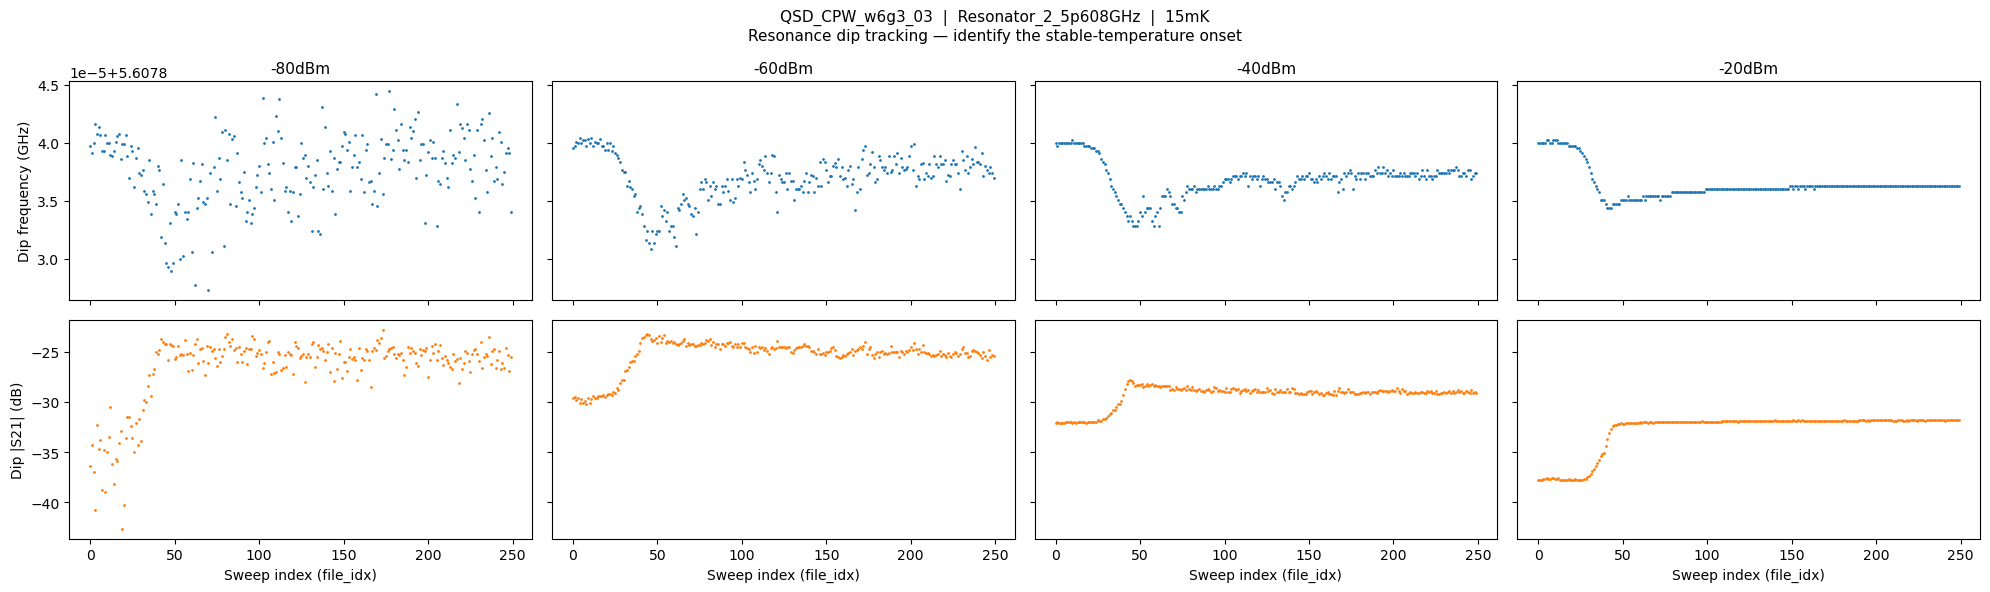


→ Inspect the plot above, then set 'trim_start_index' in the next cell.


In [10]:
# Plot dip frequency and dip |S21| vs sweep index
#
# Top row  : dip frequency (GHz) — sensitive to temperature drift
# Bottom row: dip |S21| (dB)     — sensitive to coupling / loss changes

n_pwr = len(all_powers)
fig, axes = plt.subplots(2, n_pwr,
                         figsize=(max(5 * n_pwr, 8), 6),
                         sharex='col', sharey='row')
axes = np.atleast_2d(axes).reshape(2, n_pwr)   # ensure 2-D even for 1 power

for col, pwr in enumerate(all_powers):
    d  = dip_data[pwr]
    xi = d['sweep_indices']

    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ax_top.plot(xi, d['dip_freqs_GHz'], '.', ms=2, color='C0')
    ax_bot.plot(xi, d['dip_mags_dB'],  '.', ms=2, color='C1')

    ax_top.set_title(pwr, fontsize=11)
    ax_bot.set_xlabel("Sweep index (file_idx)")

axes[0, 0].set_ylabel("Dip frequency (GHz)")
axes[1, 0].set_ylabel("Dip |S21| (dB)")

fig.suptitle(
    f"{sample_name}  |  {res_label}_{freq_str}  |  {temperature}\n"
    "Resonance dip tracking — identify the stable-temperature onset",
    fontsize=11
)
fig.tight_layout()
plt.show()

print("\n→ Inspect the plot above, then set 'trim_start_index' in the next cell.")

In [11]:
# Set trim start index
#
# After viewing the dip plot above, set the file_idx from which all
# temperatures are stable.  Sweeps BELOW this index are discarded.
# The same index is applied to every power group.

trim_start_index = 180   # UPDATE!!! 

print(f"trim_start_index = {trim_start_index}")
for pwr in all_powers:
    n_total   = len(power_groups[pwr])
    n_kept    = n_total - trim_start_index
    n_discarded = trim_start_index
    print(f"  {pwr:>10s} : keep {n_kept}/{n_total}  "
          f"(discard first {n_discarded} sweeps)")

trim_start_index = 180
      -80dBm : keep 70/250  (discard first 180 sweeps)
      -60dBm : keep 70/250  (discard first 180 sweeps)
      -40dBm : keep 70/250  (discard first 180 sweeps)
      -20dBm : keep 70/250  (discard first 180 sweeps)


In [12]:
# Copy trimmed files to a new directory
#
# Trimmed files are re-indexed from 0 within each power group.
# A new metadata_trimmed.csv records the time of each trimmed sweep:
#   time_s = trimmed_file_index × sweep_duration   (relative to trim point)

trimmed_dir = target_dir / f"{res_label}_{freq_str}_trimmed"
trimmed_dir.mkdir(parents=True, exist_ok=True)

trimmed_meta_rows = []

for pwr in all_powers:
    trimmed_idx = 0
    for orig_idx, entry in enumerate(power_groups[pwr]):
        if orig_idx < trim_start_index:
            continue

        src_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{orig_idx}.csv"
        dst_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{trimmed_idx}.csv"
        shutil.copy2(organized_dir / src_name, trimmed_dir / dst_name)

        trimmed_meta_rows.append({
            'power_str'          : pwr,
            'trimmed_file_index' : trimmed_idx,
            'orig_file_index'    : orig_idx,
            'sweep_index'        : entry['sweep_idx'],
            'unix_time'          : entry['unix_time'],
            'time_s'             : trimmed_idx * sweep_duration,
            'filename'           : dst_name,
        })
        trimmed_idx += 1

trimmed_meta_df = pd.DataFrame(trimmed_meta_rows)
trimmed_meta_df.to_csv(trimmed_dir / "metadata_trimmed.csv", index=False)

print(f"Trimmed files saved to: {trimmed_dir}")
print()
print(trimmed_meta_df.groupby('power_str')['trimmed_file_index'].count()
      .rename('n_sweeps_kept').to_string())

Trimmed files saved to: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed

power_str
-20dBm    70
-40dBm    70
-60dBm    70
-80dBm    70


## Section 3 — DCM Circle Fit for Each Sweep

For every trimmed CSV, call `fit_single_res` from *Fitting_Code_Lab_2.0* to extract
Q, Qi, Qc, and fc using the DCM method.  Results are saved as
`{sample_name}_{freq_str}_{power}_{temperature}_fit.csv` with columns:

time_s; Q; Qi; Qc; fc_Hz

Fit plots are saved under `{res_label}_{freq_str}_fit/fit_plots/`.
Set `save_individual_fit_plots = False` to skip plot saving and speed up fitting.

In [13]:
# Fitting configuration

phi0 = 0.0    # phase offset (phi0) for Qc correction — adjust if your geometry requires it

# Set to False for large datasets to avoid saving thousands of individual fit PNGs
save_individual_fit_plots = False

# Output directories
fit_dir       = target_dir / f"{res_label}_{freq_str}_fit"
fit_plots_dir = fit_dir / "fit_plots"
fit_dir.mkdir(parents=True, exist_ok=True)
fit_plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Fit results  → {fit_dir}")
print(f"Fit plots    → {fit_plots_dir}")
print(f"phi0         = {phi0}")
print(f"Save plots   : {save_individual_fit_plots}")

Fit results  → C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_fit
Fit plots    → C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_fit\fit_plots
phi0         = 0.0
Save plots   : False


In [14]:
# Run fit_single_res on every trimmed file
#
# params returned by fit_single_res: [Q, Qc_mag, fc_Hz, phi]
# Qi is derived via the DCM formula:
#   Qcj = Qc_mag * exp(i*(phi + phi0))
#   1/Qi = 1/Q - Re(1/Qcj)

for pwr in all_powers:
    print(f"\n{'='*60}")
    print(f"Fitting power: {pwr}")
    print(f"{'='*60}")

    pwr_meta = trimmed_meta_df[trimmed_meta_df['power_str'] == pwr].reset_index(drop=True)
    N = len(pwr_meta)

    times  = np.full(N, np.nan)
    Q_arr  = np.full(N, np.nan)
    Qi_arr = np.full(N, np.nan)
    Qc_arr = np.full(N, np.nan)
    fc_arr = np.full(N, np.nan)

    for row in pwr_meta.itertuples(index=False):
        i   = row.trimmed_file_index
        t   = row.time_s
        csv = trimmed_dir / row.filename

        try:
            params, err, conf_int, fig = hf.fit_single_res(
                filename          = str(csv),
                preprocess_method = 'circle',
                save_dcm_plot     = save_individual_fit_plots,
                save_fit_dirs     = str(fit_plots_dir),
                manual_init       = None,
                plot_extra        = False,
            )
            plt.close('all')

            # Derive Qi from DCM formula 
            Q_val  = params[0]
            Qcj    = params[1] * np.exp(1j * (params[3] + phi0))
            Qi_val = float(np.real(1.0 / (1.0 / Q_val - np.real(1.0 / Qcj))))
            Qc_val = float(np.real(Qcj))
            fc_val = params[2]   # Hz

            if all(np.isfinite(v) for v in [Q_val, Qi_val, Qc_val, fc_val]) \
                    and Qi_val > 0 and Qc_val > 0:
                times[i]  = t
                Q_arr[i]  = Q_val
                Qi_arr[i] = Qi_val
                Qc_arr[i] = Qc_val
                fc_arr[i] = fc_val
            else:
                print(f"  [WARN] Unphysical fit at index {i:5d} (t={t:.1f}s) — NaN stored.")

        except Exception as exc:
            print(f"  [ERR]  Fit failed  at index {i:5d} (t={t:.1f}s): {exc}")

        # Progress print every 100 sweeps
        if (i + 1) % 100 == 0 or (i + 1) == N:
            n_done = np.sum(np.isfinite(Q_arr[:i+1]))
            print(f"  [{i+1:>5d}/{N}]  successful fits so far: {n_done}")

    # Save fit results
    fit_df = pd.DataFrame({'time_s': times, 'Q': Q_arr,
                           'Qi': Qi_arr,   'Qc': Qc_arr, 'fc_Hz': fc_arr})
    out_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_fit.csv"
    fit_df.to_csv(fit_dir / out_name, index=False)

    n_good = int(np.sum(np.isfinite(Q_arr)))
    print(f"\nFit results saved : {out_name}")
    print(f"Successful fits   : {n_good} / {N}")

print("\nAll powers fitted.")


Fitting power: -80dBm
-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_0.csv
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 19.672 kHz.
Initial guess before curve fit shows that Q = 285061.
Initial guess before curve fit shows that Qc = 683375.
Initial guess before curve fit shows that phi = -0.0119 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 25.337 kHz.
Initial guess after curve fit shows that Q = 221327.
Initial guess after curve fit shows that Qc = 542127.
Initial guess after curve fit shows that phi = 0.1959 rad.
-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_1.csv
  [ERR]  Fit failed  at index  

c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Q=39684.0513553705) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Qc=82493.85688972364) = 0.7481277730713934 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(w1=5607934574.647371) = 0.0 < max(sigmas)
  warn(errmsg)


-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_4.csv
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 19.344 kHz.
Initial guess before curve fit shows that Q = 289896.
Initial guess before curve fit shows that Qc = 721369.
Initial guess before curve fit shows that phi = 0.0126 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 19.234 kHz.
Initial guess after curve fit shows that Q = 291559.
Initial guess after curve fit shows that Qc = 733822.
Initial guess after curve fit shows that phi = -0.0578 rad.
-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_5.csv
Initial guess before curve fit shows that fc = 5.6078 

-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_22.csv
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 112.104 kHz.
Initial guess before curve fit shows that Q = 50023.
Initial guess before curve fit shows that Qc = 98001.
Initial guess before curve fit shows that phi = -0.2912 rad.
Initial guess after curve fit shows that fc = 5.6079 GHz
Initial guess after curve fit shows that linewidth = 96.063 kHz.
Initial guess after curve fit shows that Q = 58377.
Initial guess after curve fit shows that Qc = 147001.
Initial guess after curve fit shows that phi = -1.0219 rad.


c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Q=29188.336078231685) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(Qc=138911.58569787556) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(w1=5607760791.200377) = 0.0 < max(sigmas)
  warn(errmsg)


...

c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Q=39765.969407970144) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(Q=71529.83809500566) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(Qc=88258.1667448309) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Qc=250489.3926229228) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(w1=5607829704.959493) = 0.0 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(w

-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_41.csv
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 21.629 kHz.
Initial guess before curve fit shows that Q = 259278.
Initial guess before curve fit shows that Qc = 586189.
Initial guess before curve fit shows that phi = 0.0078 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 26.077 kHz.
Initial guess after curve fit shows that Q = 215046.
Initial guess after curve fit shows that Qc = 487502.
Initial guess after curve fit shows that phi = 0.0638 rad.
-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_42.csv
Initial guess before curve fit shows that fc = 5.6078

c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Q=68602.10544902319) = 0.0 < max(sigmas)
  warn(errmsg)


[WARNING] fitted fc is at sweep boundary → bad fit
  [WARN] Unphysical fit at index    44 (t=7876.0s) — NaN stored.
-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-80dBm_15mK_45.csv
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 22.805 kHz.
Initial guess before curve fit shows that Q = 245900.
Initial guess before curve fit shows that Qc = 576850.
Initial guess before curve fit shows that phi = -0.1839 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 27.118 kHz.
Initial guess after curve fit shows that Q = 206793.
Initial guess after curve fit shows that Qc = 498592.
Initial guess after curve fit shows that phi = 0.0533 rad.
-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator

-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-40dBm_15mK_42.csv
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 11.399 kHz.
Initial guess before curve fit shows that Q = 491978.
Initial guess before curve fit shows that Qc = 686572.
Initial guess before curve fit shows that phi = -0.0120 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 15.089 kHz.
Initial guess after curve fit shows that Q = 371661.
Initial guess after curve fit shows that Qc = 517356.
Initial guess after curve fit shows that phi = 0.0122 rad.
-------------
fit_single_res: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_trimmed\QSD_CPW_w6g3_03_5p608GHz_-40dBm_15mK_43.csv
Initial guess before curve fit shows that fc = 5.607

## Section 4 — PSD Analysis

Compute the Power Spectral Density of **fc**, **Q**, and **Qi** for each power
using Welch's method.  The sampling frequency is `1 / sweep_duration`.

In [15]:
# Load fit results for all powers 

fit_results = {}   # cleaned DataFrame (NaN rows dropped)

for pwr in all_powers:
    fname = f"{sample_name}_{freq_str}_{pwr}_{temperature}_fit.csv"
    fpath = fit_dir / fname
    if not fpath.exists():
        print(f"[WARN] Fit results not found for {pwr}: {fpath}")
        continue

    df       = pd.read_csv(fpath)
    df_clean = df.dropna().reset_index(drop=True)
    fit_results[pwr] = df_clean

    n_total = len(df)
    n_clean = len(df_clean)
    print(f"  {pwr:>10s} : {n_clean:>5d} valid pts  "
          f"(dropped {n_total - n_clean} NaN rows)")

print()
print(f"Sampling frequency: {1/sweep_duration:.4f} Hz  "
      f"(sweep_duration = {sweep_duration:.3f} s)")

      -80dBm :    57 valid pts  (dropped 13 NaN rows)
      -60dBm :    70 valid pts  (dropped 0 NaN rows)
      -40dBm :    70 valid pts  (dropped 0 NaN rows)
      -20dBm :    70 valid pts  (dropped 0 NaN rows)

Sampling frequency: 0.0056 Hz  (sweep_duration = 179.000 s)


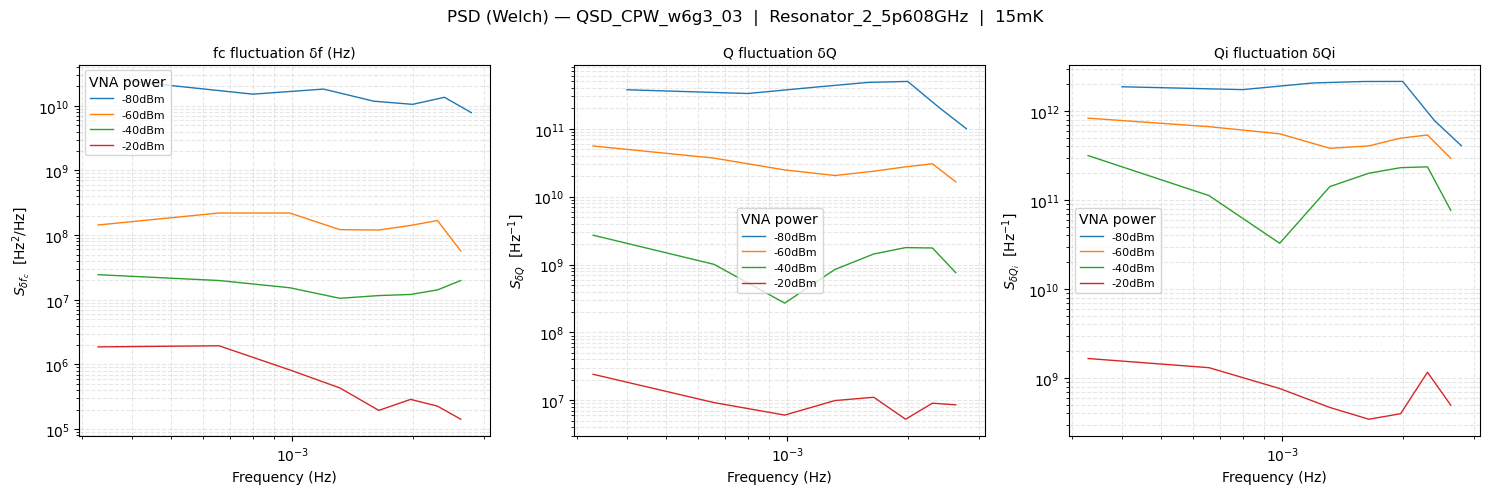

PSD plot saved: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_fit\PSD_QSD_CPW_w6g3_03_5p608GHz_15mK.png


In [16]:
# Welch PSD for fc, Q, Qi 
#
# For fc: PSD of frequency fluctuations δf = fc - mean(fc)  [units: Hz²/Hz]
# For Q, Qi: PSD of fluctuations δQ = Q - mean(Q)           [units: 1/Hz]
#
# Welch parameters — adjust nperseg for frequency resolution vs noise trade-off
nperseg  = 256    # samples per Welch segment; must be ≤ min(n_sweeps) // 4
noverlap = None   # None → 50% overlap (scipy default)

quantities = [
    ('fc_Hz', r'$S_{\delta f_c}$  [Hz$^2$/Hz]',   'fc fluctuation δf (Hz)'),
    ('Q',     r'$S_{\delta Q}$  [Hz$^{-1}$]',     'Q fluctuation δQ'),
    ('Qi',    r'$S_{\delta Q_i}$  [Hz$^{-1}$]',   'Qi fluctuation δQi'),
]

fs = 1.0 / sweep_duration

fig, axes = plt.subplots(1, len(quantities),
                         figsize=(5 * len(quantities), 5),
                         sharey=False)

for ax, (qty_key, ylabel, desc) in zip(axes, quantities):
    for pwr in all_powers:
        if pwr not in fit_results:
            continue
        y = fit_results[pwr][qty_key].values.copy()
        y -= np.mean(y)   # remove DC offset (work with fluctuations)

        seg = min(nperseg, len(y) // 4)
        if seg < 8:
            print(f"  [WARN] Too few points for Welch ({pwr}, {qty_key}) — skipping.")
            continue

        freqs_psd, Pxx = sig.welch(y, fs=fs, nperseg=seg, noverlap=noverlap)

        mask = freqs_psd > 0   # skip DC bin on log axis
        ax.loglog(freqs_psd[mask], Pxx[mask], label=pwr, lw=1)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel(ylabel)
    ax.set_title(desc, fontsize=10)
    ax.legend(fontsize=8, title="VNA power")
    ax.grid(True, which='both', alpha=0.3, ls='--')

fig.suptitle(
    f"PSD (Welch) — {sample_name}  |  {res_label}_{freq_str}  |  {temperature}",
    fontsize=12
)
fig.tight_layout()

# Save PSD figure
psd_plot_path = fit_dir / f"PSD_{sample_name}_{freq_str}_{temperature}.png"
fig.savefig(psd_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"PSD plot saved: {psd_plot_path}")

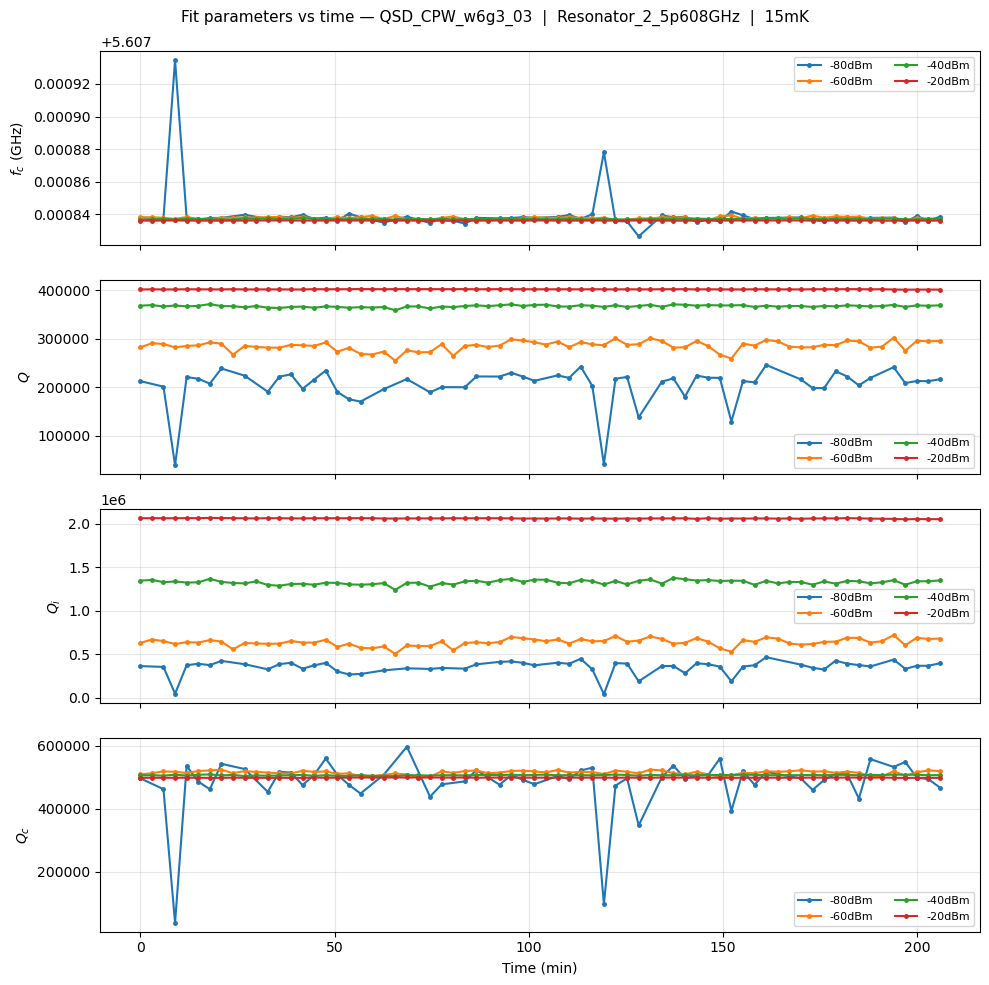

Time-domain plot saved: C:\Users\user\Downloads\Line5_QSD_CPW_w6g3_03\Test_Time_Dependent_S21_organized\Resonator_2_5p608GHz_fit\fit_vs_time_QSD_CPW_w6g3_03_5p608GHz_15mK.png


In [20]:
# Optional: plot fit parameters vs time for a quick sanity check

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

for pwr in all_powers:
    if pwr not in fit_results:
        continue
    df = fit_results[pwr]
    t  = df['time_s'].values / 60   # → minutes

    axes[0].plot(t, df['fc_Hz'].values / 1e9, '.-', ms=5, label=pwr)
    axes[1].plot(t, df['Q'].values,            '.-', ms=5, label=pwr)
    axes[2].plot(t, df['Qi'].values,           '.-', ms=5, label=pwr)
    axes[3].plot(t, df['Qc'].values,           '.-', ms=5, label=pwr)

labels = [r'$f_c$ (GHz)', r'$Q$', r'$Q_i$', r'$Q_c$']
for ax, lbl in zip(axes, labels):
    ax.set_ylabel(lbl)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (min)")
fig.suptitle(
    f"Fit parameters vs time — {sample_name}  |  {res_label}_{freq_str}  |  {temperature}",
    fontsize=11
)
fig.tight_layout()

time_plot_path = fit_dir / f"fit_vs_time_{sample_name}_{freq_str}_{temperature}.png"
fig.savefig(time_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Time-domain plot saved: {time_plot_path}")